In [1]:
import os
os.chdir('../../..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import kmedoids
import chemiscope
import polars as pl

from umap import UMAP
from sklearn.manifold import TSNE
from loguru import logger

from src.datasets import QM9Dataset
from src.non_euclidean import Grassmann, Riemann
from src.helper_functions import find_best_kmedoids_k

In [3]:
qm9 = QM9Dataset()
qm9.load()
frames = qm9.get_positions()

2026-03-17 16:59:14.523 | INFO     | src.datasets:load:132 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-17 16:59:17.368 | SUCCESS  | src.datasets:get_positions:709 - Saved 2000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 2000).


In [4]:
def get_or_create_matrix(file_path, compute_func):
    if os.path.exists(file_path):
        logger.info(f"Loading existing matrix from {file_path}")
        return np.load(file_path)
    
    logger.warning(f"File {file_path} not found. Computing...")
    matrix = compute_func()
    
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    np.save(file_path, matrix)
    logger.success(f"Saved computed matrix to {file_path}")
    return matrix


folder = "matrices"

g_dist = get_or_create_matrix(
    os.path.join(folder, "g_dist.npy"), 
    lambda: Grassmann.distance_matrix(frames)
)

r_dist = get_or_create_matrix(
    os.path.join(folder, "r_dist.npy"), 
    lambda: Riemann.distance_matrix(frames, metric='affine-invariant')
)

g_dist_norm = get_or_create_matrix(
    os.path.join(folder, "g_dist_norm.npy"), 
    lambda: Grassmann.distance_matrix(frames, normalized=True)
)

r_dist_norm = get_or_create_matrix(
    os.path.join(folder, "r_dist_norm.npy"), 
    lambda: Riemann.distance_matrix(frames, normalized=True, metric='affine-invariant')
)

2026-03-17 16:59:17.376 | INFO     | __main__:get_or_create_matrix:3 - Loading existing matrix from matrices/g_dist.npy
2026-03-17 16:59:17.400 | INFO     | __main__:get_or_create_matrix:3 - Loading existing matrix from matrices/r_dist.npy
2026-03-17 16:59:17.416 | INFO     | __main__:get_or_create_matrix:3 - Loading existing matrix from matrices/g_dist_norm.npy
2026-03-17 16:59:17.441 | INFO     | __main__:get_or_create_matrix:3 - Loading existing matrix from matrices/r_dist_norm.npy


In [5]:
grassmann_k = find_best_kmedoids_k(g_dist, k_range=range(2, 15), random_state=42)
grassmann_k_scaled = find_best_kmedoids_k(g_dist_norm, k_range=range(2, 15), random_state=42)

riemann_k = find_best_kmedoids_k(r_dist, k_range=range(2, 15), random_state=42)
riemann_k_scaled = find_best_kmedoids_k(r_dist_norm, k_range=range(2, 15), random_state=42)

2026-03-17 16:59:17.474 | WARNING  | src.helper_functions:find_best_kmedoids_k:173 - feature_matrix is None; Calinski-Harabasz will be computed on dist_matrix (treated as features). Provide feature_matrix for a more meaningful CH score.
2026-03-17 16:59:19.169 | WARNING  | src.helper_functions:find_best_kmedoids_k:173 - feature_matrix is None; Calinski-Harabasz will be computed on dist_matrix (treated as features). Provide feature_matrix for a more meaningful CH score.
2026-03-17 16:59:20.549 | WARNING  | src.helper_functions:find_best_kmedoids_k:173 - feature_matrix is None; Calinski-Harabasz will be computed on dist_matrix (treated as features). Provide feature_matrix for a more meaningful CH score.
2026-03-17 16:59:21.698 | WARNING  | src.helper_functions:find_best_kmedoids_k:173 - feature_matrix is None; Calinski-Harabasz will be computed on dist_matrix (treated as features). Provide feature_matrix for a more meaningful CH score.


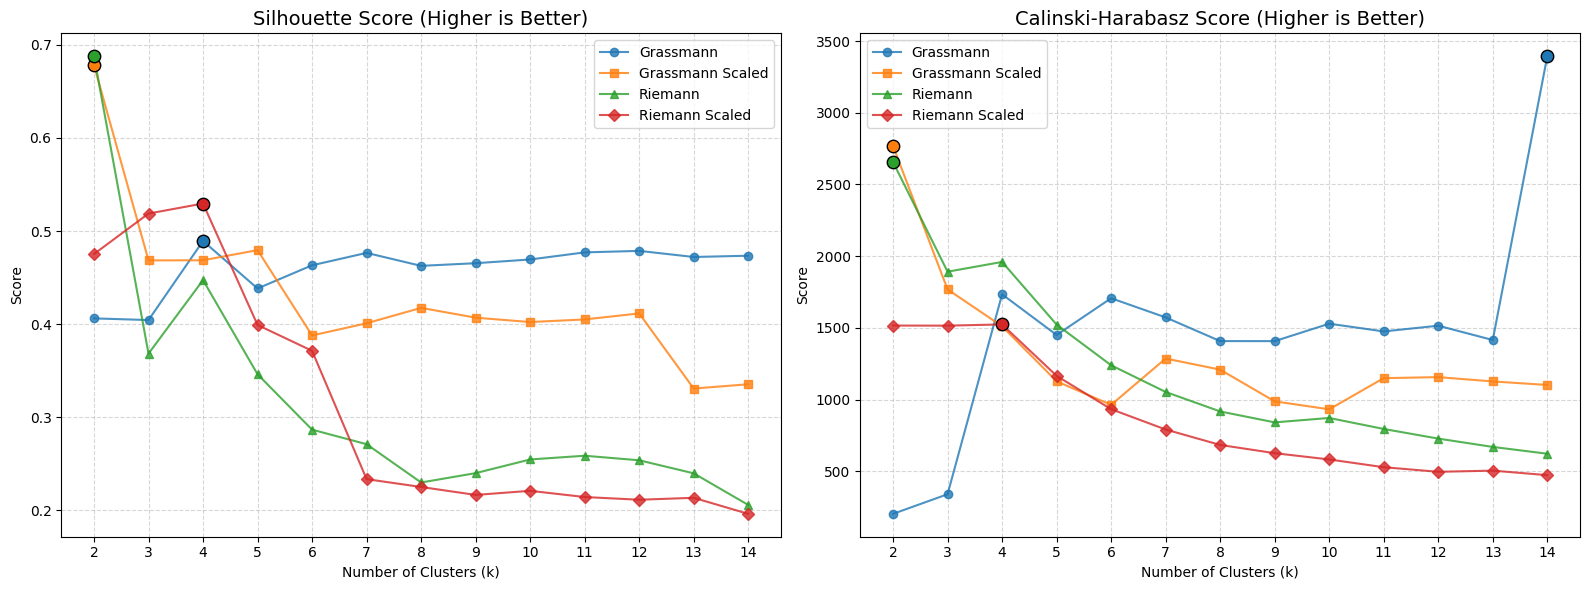

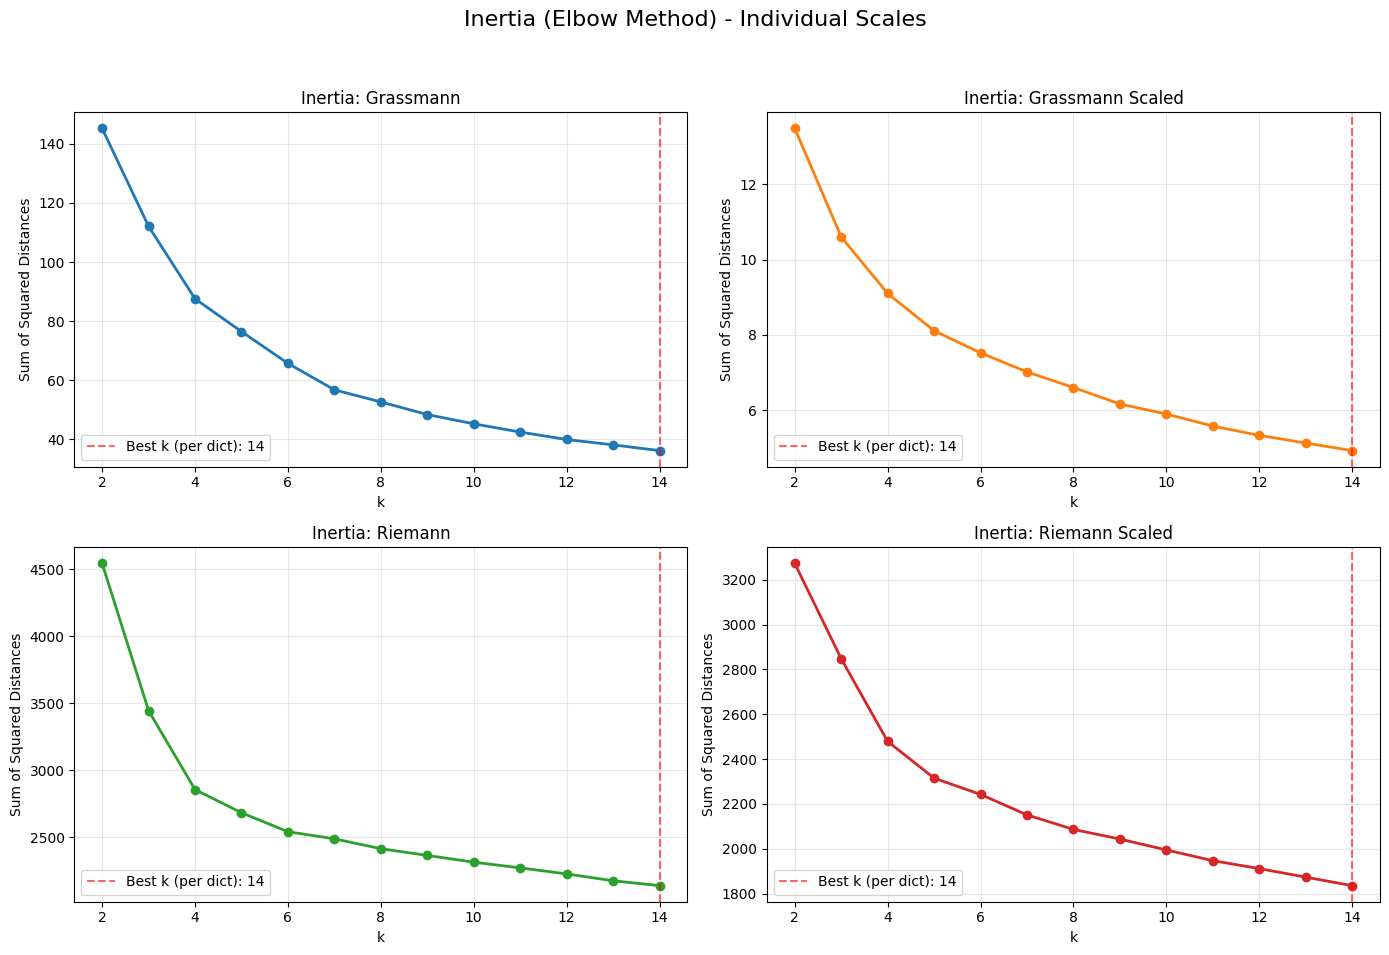

In [6]:
def plot_comparative_metrics(results_list, labels):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    metrics = ['silhouette', 'ch']
    titles = ['Silhouette Score (Higher is Better)', 'Calinski-Harabasz Score (Higher is Better)']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    markers = ['o', 's', '^', 'D']

    for ax, metric, title in zip(axes, metrics, titles):
        for i, (res, label) in enumerate(zip(results_list, labels)):
            k_values = res['results']['k']
            scores = res['results'][metric]
            best_k = res['best_k'][metric]
            
            ax.plot(k_values, scores, label=label, color=colors[i], marker=markers[i], alpha=0.8)
            
            best_score = scores[k_values.index(best_k)]
            ax.scatter(best_k, best_score, color=colors[i], s=80, edgecolors='black', zorder=5)
            
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Number of Clusters (k)")
        ax.set_ylabel("Score")
        ax.set_xticks(k_values)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

    plt.tight_layout()
    plt.savefig("clustering_comparative_metrics.png")
    plt.show()

def plot_inertia_grid(results_list, labels):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (res, label) in enumerate(zip(results_list, labels)):
        ax = axes[i]
        k_values = res['results']['k']
        inertia = res['results']['inertia']
        best_k = res['best_k']['inertia']
        
        ax.plot(k_values, inertia, color=colors[i], marker='o', linewidth=2)
        ax.axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'Best k (per dict): {best_k}')
        
        ax.set_title(f"Inertia: {label}", fontsize=12)
        ax.set_xlabel("k")
        ax.set_ylabel("Sum of Squared Distances")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle("Inertia (Elbow Method) - Individual Scales", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("clustering_inertia_individual.png")
    plt.show()

all_results = [grassmann_k, grassmann_k_scaled, riemann_k, riemann_k_scaled]
all_labels = ["Grassmann", "Grassmann Scaled", "Riemann", "Riemann Scaled"]

plot_comparative_metrics(all_results, all_labels)
plot_inertia_grid(all_results, all_labels)

In [17]:
def cluster_precomputed(dist_matrix: np.ndarray, n_clusters: int):
    model = kmedoids.KMedoids(n_clusters=n_clusters, metric="precomputed", random_state=42)
    return model.fit_predict(dist_matrix)

labels_grass = cluster_precomputed(g_dist, n_clusters=7)
labels_grass_norm = cluster_precomputed(g_dist_norm, n_clusters=5)
labels_rie = cluster_precomputed(r_dist, n_clusters=4)
labels_rie_norm = cluster_precomputed(r_dist_norm, n_clusters=4)

qm9.df = qm9.df.with_columns([
    pl.Series("cluster_grass", labels_grass),
    pl.Series("cluster_grass_norm", labels_grass_norm),
    pl.Series("cluster_rie", labels_rie),
    pl.Series("cluster_rie_norm", labels_rie_norm),
])

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
X_grass_u = reducer.fit_transform(g_dist)
X_grass_norm_u = reducer.fit_transform(g_dist_norm)
X_riemann_u = reducer.fit_transform(r_dist)
X_riemann_norm_u = reducer.fit_transform(r_dist_norm)

tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42, perplexity=30)
X_grass_t = tsne.fit_transform(g_dist)
X_grass_norm_t = tsne.fit_transform(g_dist_norm)
X_riemann_t = tsne.fit_transform(r_dist)
X_riemann_norm_t = tsne.fit_transform(r_dist_norm)

# Grassmann

In [8]:
properties = {
    "X": X_grass_t[:, 0],
    "Y": X_grass_t[:, 1],
    "Cluster": labels_grass,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups":  qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Branching index": qm9.df["branching_index"].to_list(),
    "Main chain length": qm9.df["main_chain_length"].to_list(),
    "mu": qm9.df["mu"].to_list(),
    "Homo" : qm9.df["homo"].to_list(),
    "Lumo":qm9.df["lumo"].to_list(),
    "gap": qm9.df["gap"].to_list(),
    "r2":qm9.df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, 'data': 'str…

## Grassmann Normalized

In [9]:
properties = {
    "X": X_grass_norm_t[:, 0],
    "Y": X_grass_norm_t[:, 1],
    "Cluster": labels_grass_norm,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups":  qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Branching index": qm9.df["branching_index"].to_list(),
    "Main chain length": qm9.df["main_chain_length"].to_list(),
    "mu": qm9.df["mu"].to_list(),
    "Homo" : qm9.df["homo"].to_list(),
    "Lumo":qm9.df["lumo"].to_list(),
    "gap": qm9.df["gap"].to_list(),
    "r2":qm9.df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, 'data': 'str…

# Riemann

In [15]:
properties = {
    "X": X_riemann_t[:, 0],
    "Y": X_riemann_t[:, 1],
    "Cluster": labels_rie,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups":  qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Branching index": qm9.df["branching_index"].to_list(),
    "Main chain length": qm9.df["main_chain_length"].to_list(),
    "mu": qm9.df["mu"].to_list(),
    "Homo" : qm9.df["homo"].to_list(),
    "Lumo":qm9.df["lumo"].to_list(),
    "gap": qm9.df["gap"].to_list(),
    "r2":qm9.df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, 'data': 'str…

## Normalized

In [16]:
properties = {
    "X": X_riemann_norm_t[:, 0],
    "Y": X_riemann_norm_t[:, 1],
    "Cluster": labels_rie_norm,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups":  qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Branching index": qm9.df["branching_index"].to_list(),
    "Main chain length": qm9.df["main_chain_length"].to_list(),
    "mu": qm9.df["mu"].to_list(),
    "Homo" : qm9.df["homo"].to_list(),
    "Lumo":qm9.df["lumo"].to_list(),
    "gap": qm9.df["gap"].to_list(),
    "r2":qm9.df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 5, 'data': 'structure-0'}, {'size': 4, 'data': 'str…